In [1]:
%load_ext autoreload
%autoreload 2

In [55]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neural_network import MLPClassifier
import random
import matplotlib.pyplot as plt

## Setup Data + Model

array([1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 0.], dtype=float16)

In [50]:
def generate_dataset(n):
    d = 10
    X = np.random.random((2*n,d))
    c1, c2 = np.mean(X[:,:d//2],axis=1),np.mean(X[:,d//2:],axis=1)
    c1_binary, c2_binary = (c1>0.5).round(), (c2>0.5).round()
    concepts = np.vstack([c1_binary, c2_binary]).T
    y = (c1_binary != c2_binary).round()

    data = list(range(2*n))
    random.shuffle(data)

    train_size = n
    train = data[:train_size]
    test = data[train_size:]
    X_train, c_train, y_train = X[train],concepts[train],y[train]
    X_test, c_test, y_test = X[test],concepts[test],y[test]
    return X_train, X_test, y_train, y_test

In [51]:
def get_acc(X_train,y_train,X_test,y_test):
    model_raw = MLPClassifier()
    model_raw.fit(X_train,y_train)
    y_pred = model_raw.predict(X_test)
    y_pred = (y_pred > 0.5).round()
    acc = np.mean(y_pred == y_test)
    return acc

In [ ]:
model_raw = MLPClassifier()
model_raw.fit(X_train,y_train)
y_pred = model_raw.predict(X_test)
y_pred = (y_pred > 0.5).round()
acc = np.mean(y_pred == y_test)

In [53]:
val_by_n = []
n_vals = [10,50,100,250,500,1000]

for n in n_vals:
    all_acc = []
    for trial in range(10):
        X_train, X_test, y_train, y_test = generate_dataset(n)
        acc = get_acc(X_train,y_train,X_test,y_test)
        all_acc.append(acc)
    val_by_n.append(np.mean(all_acc))
val_by_n

/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr0/home/naveenr/.local/li

[0.53, 0.5360000000000001, 0.556, 0.6628000000000001, 0.746, 0.8201]

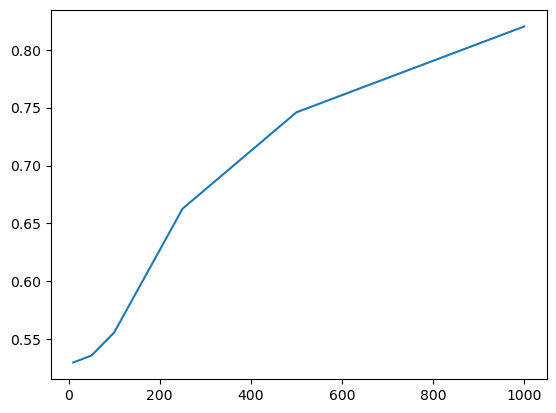

In [56]:
plt.plot(n_vals,val_by_n)

In [21]:
y_pred

array([-1.51831331,  0.96083119,  1.77533055,  0.34141159,  1.24242071,
        0.98889468])

In [3]:
concepts = 20
train_n = 1000
test_n = 100
d = 10
y_class = 5

In [94]:
train_X = np.random.random((train_n,d))
W_c = np.random.random((d,concepts))-0.5
W_y = np.random.random((concepts,y_class))-0.5
train_C = train_X.dot(W_c)
train_C += (np.random.random(train_C.shape)-0.5)/5
train_Y = np.argmax(train_C.dot(W_y),axis=1)


In [95]:
test_X = np.random.random((train_n,d))
test_C = test_X.dot(W_c)
test_C += (np.random.random(test_C.shape)-0.5)/5
test_Y = np.argmax(test_C.dot(W_y),axis=1)


In [122]:
model_C = LinearRegression()
mean_by_concept = [(np.random.random()-0.5) for i in range(concepts)]
pred_C = model_C.fit(train_X, train_C+np.random.normal(mean_by_concept,0.1,(train_C.shape)))

clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
clf.fit(train_C, train_Y)

test_pred_Y = clf.predict(model_C.predict(test_X))
np.sum(test_pred_Y == test_Y)/len(test_Y)

0.811

In [123]:
train_pred_C = model_C.predict(train_X)
sorted_acc = np.mean(np.abs(train_pred_C-train_C),axis=0)

In [124]:
sorted_acc

array([0.1252641 , 0.43781168, 0.18422457, 0.41464735, 0.21939725,
       0.15096556, 0.27537892, 0.08332808, 0.43685943, 0.2228548 ,
       0.30446237, 0.05230351, 0.37522286, 0.26006568, 0.1125093 ,
       0.05719586, 0.46066442, 0.23049532, 0.45288837, 0.21169414])

In [138]:
avg_by_agent = [[] for i in range(concepts)]

impact_by_intervention = []
all_acc = []
trials = 1000
for i in range(trials):
    selected_concepts = random.sample(list(range(concepts)),5)
    pred_C = model_C.predict(test_X)
    pred_C[:,selected_concepts] = test_C[:,selected_concepts]
    test_pred_Y = clf.predict(pred_C)
    acc = np.sum(test_pred_Y == test_Y)/len(test_Y)
    
    for j in selected_concepts:
        curr_concepts = [k for k in selected_concepts if k!=j]
        pred_C = model_C.predict(test_X)
        pred_C[:,curr_concepts] = test_C[:,curr_concepts]
        test_pred_Y = clf.predict(pred_C)
        new_acc = np.sum(test_pred_Y == test_Y)/len(test_Y)
        avg_by_agent[j].append(acc-new_acc)
for i in range(len(avg_by_agent)):
    avg_by_agent[i] = np.mean(avg_by_agent[i])
avg_by_agent

[-0.0027500000000000007,
 0.016817813765182186,
 0.011089361702127659,
 -0.07692857142857143,
 -0.008565573770491802,
 4.9242424242425546e-05,
 0.024435555555555565,
 0.018607305936073064,
 0.07079098360655739,
 -0.009973180076628355,
 -0.0794538745387454,
 0.0032570281124498003,
 0.08033846153846155,
 -0.002751937984496123,
 -0.008461832061068705,
 0.008821862348178137,
 -0.0494920634920635,
 0.018339483394833954,
 0.06609890109890112,
 -0.01759349593495935]

In [139]:
num_interventions = [0,2,5,10,15,20]
for num_intervene in num_interventions:
    pred_C = model_C.predict(test_X)
    selected_concepts = random.sample(list(range(concepts)),num_intervene)
    pred_C[:,selected_concepts] = test_C[:,selected_concepts]
    test_pred_Y = clf.predict(pred_C)
    acc = np.sum(test_pred_Y == test_Y)/len(test_Y)
    print(num_intervene,acc)

0 0.811
2 0.808
5 0.743
10 0.931
15 0.927
20 0.932


In [143]:
num_interventions = [0,2,5,10,15,20]
for num_intervene in num_interventions:
    pred_C = model_C.predict(test_X)
    if num_intervene == 0:
        selected_concepts = []
    else:
        selected_concepts = np.argsort(sorted_acc)[-num_intervene:]
    pred_C[:,selected_concepts] = test_C[:,selected_concepts]
    test_pred_Y = clf.predict(pred_C)
    acc = np.sum(test_pred_Y == test_Y)/len(test_Y)
    print(num_intervene,acc)

0 0.811
2 0.86
5 0.911
10 0.924
15 0.941
20 0.932
